In [3]:
# ============================================================
# 셀 16. 라이브러리 + 전처리 결과 불러오기
# ============================================================
import os, json, time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (recall_score, precision_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("torch :", torch.__version__)
print("device:", device)
if device.type == "cuda":
    print("GPU   :", torch.cuda.get_device_name(0))
print("np =", np.__name__, "/ pd =", pd.__name__)

torch : 2.11.0+cu128
device: cuda
GPU   : NVIDIA GeForce RTX 5060 Laptop GPU
np = numpy / pd = pandas


In [5]:
# ============================================================
# 셀 17. 전처리 결과 읽기 (다시 계산하지 않는다)
# ============================================================
df = pd.read_csv('index_split.csv')

with open('preprocess_meta.json', encoding='utf-8') as f:
    meta = json.load(f)

IMAGE_SIZE = meta['IMAGE_SIZE']
MEAN = np.array(meta['MEAN'], dtype=np.float32)
STD  = np.array(meta['STD'],  dtype=np.float32)

print("표 크기:", df.shape)
print("컬럼   :", list(df.columns))
print()
print(df.groupby('split').agg(
    환자수   = ('patient', 'nunique'),
    슬라이스 = ('patient', 'size'),
    종양비율 = ('tumor', 'mean'),
).reindex(['train', 'val', 'test']).round(3))
print()
print("IMAGE_SIZE:", IMAGE_SIZE)
print("MEAN:", MEAN.round(4))
print("STD :", STD.round(4))

표 크기: (3929, 8)
컬럼   : ['patient', 'slice', 'image', 'mask', 'tumor', 'tumor_px', 'inst', 'split']

       환자수  슬라이스   종양비율
split                  
train   78  2742  0.345
val     16   565  0.375
test    16   622  0.344

IMAGE_SIZE: 256
MEAN: [0.0858 0.0822 0.0891]
STD : [0.1302 0.1223 0.1301]


# 메모리에 적재

In [6]:
# ============================================================
# 셀 18. 이미지를 RAM에 올린다  [5번 노트북 build_dataset]
# ============================================================
from tqdm.auto import tqdm

def build_dataset(sub_df, desc):
    imgs = np.zeros((len(sub_df), IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
    msks = np.zeros((len(sub_df), IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
    for i, (_, r) in enumerate(tqdm(sub_df.iterrows(), total=len(sub_df), desc=desc)):
        imgs[i] = cv2.imread(r['image'], cv2.IMREAD_UNCHANGED)[:, :, ::-1]
        msks[i] = (cv2.imread(r['mask'], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
    return imgs, msks

t0 = time.time()
data = {}
for sp in ['train', 'val', 'test']:
    sub = df[df.split == sp].reset_index(drop=True)
    data[sp] = (*build_dataset(sub, sp), sub)

total_gb = sum(a.nbytes + b.nbytes for a, b, _ in data.values()) / 1024**3
print(f"\n적재 {time.time()-t0:.1f}초 | {total_gb:.2f} GB")
print("train imgs:", data['train'][0].shape, data['train'][0].dtype)
print("train msks:", data['train'][1].shape, data['train'][1].dtype)

train:   0%|          | 0/2742 [00:00<?, ?it/s]

val:   0%|          | 0/565 [00:00<?, ?it/s]

test:   0%|          | 0/622 [00:00<?, ?it/s]


적재 10.4초 | 0.96 GB
train imgs: (2742, 256, 256, 3) uint8
train msks: (2742, 256, 256) uint8


In [ ]:
# ============================================================
# 셀 19. Dataset  [5번 노트북 SegDataset 변형]
# ============================================================
class SegDataset(Dataset):
    def __init__(self, imgs, msks, sub_df, neg_ratio=None, augment=False, seed=SEED):
        self.imgs, self.msks, self.sub = imgs, msks, sub_df
        self.neg_ratio, self.augment = neg_ratio, augment
        self.pos_idx = np.where(sub_df['tumor'].values == 1)[0]   # 종양 있는 슬라이스
        self.neg_idx = np.where(sub_df['tumor'].values == 0)[0]   # 빈 슬라이스
        self.rng = np.random.default_rng(seed)
        self.resample_epoch()

    def resample_epoch(self):
        """에폭마다 빈 슬라이스를 새로 뽑는다"""
        if self.neg_ratio is None:                # val / test는 전체 사용
            self.rows = np.arange(len(self.sub))
            return
        k = min(int(len(self.pos_idx) * self.neg_ratio), len(self.neg_idx)) # 매에폭마다 다르게 뽑기
        pick = self.rng.choice(self.neg_idx, size=k, replace=False) # 중복없이 뽑기
        self.rows = np.concatenate([self.pos_idx, pick])

    def __len__(self):
        return len(self.rows) # 이번 에폭에 쓸 슬라이스 번호 목록이라는 뜻

    def __getitem__(self, i): # 데이터를 복사하지 않고 번호만 바꿔서 재샘플링 하는것.
        j = self.rows[i]
        img = self.imgs[j].astype(np.float32) / 255.0
        msk = self.msks[j].astype(np.float32)

        if self.augment:                          # 이미지와 마스크에 똑같이 (실시간 증강)
            if self.rng.random() < 0.5: img, msk = img[:, ::-1], msk[:, ::-1]
            if self.rng.random() < 0.5: img, msk = img[::-1],    msk[::-1]
            k = int(self.rng.integers(4))
            if k: img, msk = np.rot90(img, k), np.rot90(msk, k)
            img, msk = np.ascontiguousarray(img), np.ascontiguousarray(msk)

        img = np.transpose((img - MEAN) / STD, (2, 0, 1))   # 정규화는 이미지만
        return torch.from_numpy(img).float(), torch.from_numpy(msk)[None].float()

print("SegDataset 정의 완료")



SegDataset 정의 완료


In [ ]:
# ============================================================
# 셀 20. DataLoader 생성
# ============================================================
BATCH_SIZE  = 16
NEG_RATIO   = 1.0
NUM_WORKERS = 0                          # 윈도우 주피터는 0
PIN_MEMORY  = (device.type == "cuda")

def make_loaders(neg_ratio=NEG_RATIO, augment=True, seed=SEED, batch=BATCH_SIZE):
    tr = SegDataset(*data['train'], neg_ratio=neg_ratio, augment=augment, seed=seed)
    va = SegDataset(*data['val'],   neg_ratio=None, augment=False)
    te = SegDataset(*data['test'],  neg_ratio=None, augment=False)
    kw = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    return (tr,
            DataLoader(tr, batch_size=batch, shuffle=True,  **kw), # 학습데이터만 섞기
            DataLoader(va, batch_size=batch, shuffle=False, **kw),
            DataLoader(te, batch_size=batch, shuffle=False, **kw))

train_ds, train_loader, val_loader, test_loader = make_loaders()

print("에폭당 학습 장수:", len(train_ds))
print(f"  종양 {len(train_ds.pos_idx)}장 + 빈 슬라이스 {len(train_ds) - len(train_ds.pos_idx)}장")
print("val :", len(val_loader.dataset), "장 (전체 사용)")
print("test:", len(test_loader.dataset), "장 (전체 사용)")
print()

xb, yb = next(iter(train_loader)) # 배치하나만 꺼내서 확인하기.
print("배치 하나")
print("  이미지:", tuple(xb.shape), xb.dtype)
print("  마스크:", tuple(yb.shape), yb.dtype, "| 값:", yb.unique().tolist())
print(f"  이미지 범위: {xb.min():.2f} ~ {xb.max():.2f}  (정규화됨)")

# 이미지 범위 : 정규화가 됫다는 증거임 원래 0~1이였으나 평균을 뺴서 음수가 생김
# -0.68~7.00 : 가장 어두운배경은 -0.68 / 가장 밝은 픽셀 7.02
# 마스크값 0.0, 1.0만 있음 255가 석여있으면 변환안된증거.
# 마스크 shape에 채널 1이 있음.

에폭당 학습 장수: 1894
  종양 947장 + 빈 슬라이스 947장
val : 565 장 (전체 사용)
test: 622 장 (전체 사용)

배치 하나
  이미지: (16, 3, 256, 256) torch.float32
  마스크: (16, 1, 256, 256) torch.float32 | 값: [0.0, 1.0]
  이미지 범위: -0.68 ~ 7.00  (정규화됨)


# 증강 확인하기
## 증강이미지와 마스크에 똑같이 걸리는지 확인

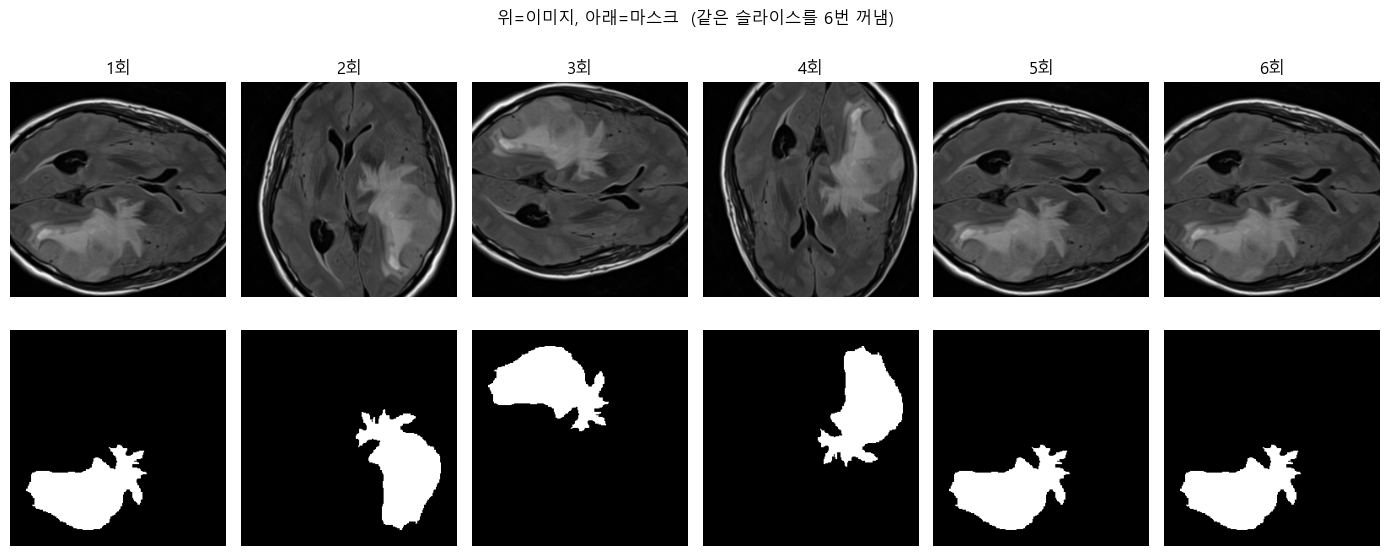

In [ ]:
# ============================================================
# 셀 21. 증강이 이미지와 마스크에 동일하게 적용되는지 확인
# ============================================================
# 종양이 큰 슬라이스 하나 고르기 (변형이 잘 보이게)
tr_imgs, tr_msks, tr_sub = data['train']
pick = tr_sub['tumor_px'].idxmax() # 큰 종양으로 고르기

check_ds = SegDataset(tr_imgs, tr_msks, tr_sub, neg_ratio=None, augment=True, seed=0)
# 

plt.figure(figsize=(14, 6))
for c in range(6):
    img, msk = check_ds[pick]                      # 같은 슬라이스를 6번 꺼낸다
    flair = img[1].numpy()                         # 채널 1 = FLAIR
    m = msk[0].numpy()

    plt.subplot(2, 6, c + 1)
    plt.imshow(flair, cmap='gray'); plt.axis('off')
    if c == 0: plt.ylabel('FLAIR')
    plt.title(f'{c+1}회')

    plt.subplot(2, 6, c + 7)
    plt.imshow(m, cmap='gray'); plt.axis('off')

plt.suptitle('위=이미지, 아래=마스크  (같은 슬라이스를 6번 꺼냄)')
plt.tight_layout(); plt.show()

# 증강은 꺼낼떄마다 무작위로 일어남. / 실시간증강으로 미리 만들어두어 다 똑같이 나오게함.
# 위아래가 같은방향인지 확인하기
# 6장 사진이 서로 다른가 / 매번 다른변형이 되야 증강이 된것.
# 뇌모양이 자연스러운지 - 찌그러지거나 잘려지면 안됨.
# 1회 5회 6회 비슷해보이는것도 정ㅅ아임 -> 8가지 방향밖에 없어서 6번 뽑으면 겹치는게 나오는게 정상임.

# u-net
## 이진 분할용으로 바꾸는과정

In [ ]:
# ============================================================
# 셀 22. U-Net  [5번 노트북 구조]
# ============================================================
def conv2d_block(in_ch, out_ch, kernel_size=3, use_bn=True):
    layers = []
    for i in range(2):
        layers += [nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, kernel_size,
                             padding=kernel_size // 2, bias=not use_bn)]
        if use_bn:
            layers += [nn.BatchNorm2d(out_ch)]        # [2번 노트북]
        layers += [nn.ReLU(inplace=True)]
    return nn.Sequential(*layers)


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.2, use_bn=True):
        super().__init__()
        self.conv = conv2d_block(in_ch, out_ch, use_bn=use_bn)
        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        f = self.conv(x)                # skip connection 으로 내보낼 것
        return f, self.drop(self.pool(f))


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.2, use_bn=True):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 3, stride=2,
                                       padding=1, output_padding=1)  # 해상도 2배키움.
        self.drop = nn.Dropout(dropout)
        self.conv = conv2d_block(out_ch + skip_ch, out_ch, use_bn=use_bn)

    def forward(self, x, skip):
        return self.conv(self.drop(torch.cat([self.up(x), skip], dim=1)))

print("블록 정의 완료")

# 분할의 딜레마 -> CNN은 층을 지날수록 해상도를 줄임
# 그러나 출력은 다시 256 X  256이어야함. -> 위치가 뭉게지기 떄문
# Skip connection 사용해서 줄이기 전 고해상도 정보를 디코더로 직접 전달함 -> 7픽셀 종양 잡기위해.



블록 정의 완료


In [ ]:
# ============================================================
# 셀 23. U-Net 본체  [5번 노트북 구조, 출력만 1채널로]
# ============================================================
BASE = 32          # 첫 인코더 채널 수

class UNet(nn.Module):
    def __init__(self, base=BASE, in_ch=3, n_classes=1, use_bn=True):
        super().__init__()
        b = base
        # 인코더: 채널을 2배씩 늘리고 해상도를 절반씩 줄인다
        self.enc1 = EncoderBlock(in_ch, b,   use_bn=use_bn)    # 256 -> 128
        self.enc2 = EncoderBlock(b,     b*2, use_bn=use_bn)    # 128 -> 64
        self.enc3 = EncoderBlock(b*2,   b*4, use_bn=use_bn)    # 64  -> 32
        self.enc4 = EncoderBlock(b*4,   b*8, use_bn=use_bn)    # 32  -> 16

        self.bottleneck = conv2d_block(b*8, b*16, use_bn=use_bn)   # 16, 512채널

        # 디코더: 해상도를 2배씩 키우고 skip 을 이어붙인다
        self.dec1 = DecoderBlock(b*16, b*8, b*8, use_bn=use_bn)    # 16 -> 32
        self.dec2 = DecoderBlock(b*8,  b*4, b*4, use_bn=use_bn)    # 32 -> 64
        self.dec3 = DecoderBlock(b*4,  b*2, b*2, use_bn=use_bn)    # 64 -> 128
        self.dec4 = DecoderBlock(b*2,  b,   b,   use_bn=use_bn)    # 128 -> 256

        self.out = nn.Conv2d(b, n_classes, 1)     # 1x1 conv 로 채널만 1개로
        self._init_weights()

    def _init_weights(self):                      # [2번 노트북]
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        f1, p1 = self.enc1(x)      # f = skip, p = 다음 층으로
        f2, p2 = self.enc2(p1)
        f3, p3 = self.enc3(p2)
        f4, p4 = self.enc4(p3)

        c = self.bottleneck(p4)

        c = self.dec1(c, f4)       # skip 을 거꾸로 이어붙인다
        c = self.dec2(c, f3)
        c = self.dec3(c, f2)
        c = self.dec4(c, f1)
        return self.out(c)


# 확인
m = UNet(base=BASE, use_bn=True)
with torch.no_grad():
    out = m(torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE))
print("입력:", (2, 3, IMAGE_SIZE, IMAGE_SIZE))
print("출력:", tuple(out.shape))
print()
for bn in [True, False]:
    mm = UNet(base=BASE, use_bn=bn)
    print(f"use_bn={str(bn):5s} 파라미터 {sum(p.numel() for p in mm.parameters()):,}")
del m, mm

# 초기값 적당한 크기로 잡아줌.

입력: (2, 3, 256, 256)
출력: (2, 1, 256, 256)

use_bn=True  파라미터 8,633,441
use_bn=False 파라미터 8,630,497


# 손실함수

In [ ]:
# ============================================================
# 셀 24. 손실함수  [5번은 CrossEntropy, 여기는 BCE + Dice]
# ============================================================
class BCEDiceLoss(nn.Module):
    def __init__(self, w_bce=0.5, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()      # [4번 노트북]
        self.w, self.s = w_bce, smooth

    def forward(self, logits, target):
        logits, target = logits.float(), target.float()   # AMP 오버플로 방지

        bce = self.bce(logits, target)

        p = torch.sigmoid(logits)
        inter = (p * target).sum(dim=(1, 2, 3))                       # 겹친 부분
        den   = p.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))      # 예측 + 정답
        dice  = 1 - ((2 * inter + self.s) / (den + self.s)).mean()

        return self.w * bce + (1 - self.w) * dice


class TverskyLoss(nn.Module):
    """beta > alpha 이면 놓침(FN)을 더 싫어한다 -> 재현율 중시"""
    def __init__(self, alpha=0.3, beta=0.7, smooth=1.0):
        super().__init__()
        self.a, self.b, self.s = alpha, beta, smooth

    def forward(self, logits, target):
        logits, target = logits.float(), target.float()

        p  = torch.sigmoid(logits)
        tp = (p * target).sum(dim=(1, 2, 3))              # 맞게 찾음
        fp = (p * (1 - target)).sum(dim=(1, 2, 3))        # 오탐
        fn = ((1 - p) * target).sum(dim=(1, 2, 3))        # 놓침

        return (1 - (tp + self.s) / (tp + self.a * fp + self.b * fn + self.s)).mean()

print("손실함수 정의 완료")

# 30개중 몇번이냐를 맞히는 손실임. 정답이 정수 라벨임.
# 클래스 한개라 종양일 확률이 얼마냐를 맞힘. 
# 이부분만 다시 공부하기

손실함수 정의 완료


In [ ]:
# ============================================================
# 셀 25. 손실함수가 의도대로 동작하는지 검증
# ============================================================
print("① 빈 마스크에서 nan 이 안 나는가")
logits = torch.randn(4, 1, 256, 256)
empty  = torch.zeros(4, 1, 256, 256)
print("   BCE+Dice:", round(BCEDiceLoss()(logits, empty).item(), 4))
print("   Tversky :", round(TverskyLoss()(logits, empty).item(), 4))

print()
print("② 그래디언트가 흐르는가")
lg = torch.randn(2, 1, 256, 256, requires_grad=True)
tgt = (torch.rand(2, 1, 256, 256) > 0.98).float()
BCEDiceLoss()(lg, tgt).backward()
print("   그래디언트 노름:", round(lg.grad.norm().item(), 6))

print()
print("③ Tversky beta 가 놓침을 더 싫어하는가")
# 오차 픽셀 수를 똑같이 32개로 맞춘 두 오답
tgt2  = torch.zeros(1, 1, 20, 20); tgt2[0, 0, 5:13, 5:13] = 1.0     # 정답 64px
under = torch.full((1, 1, 20, 20), -6.0); under[0, 0, 5:13, 5:9]  = 6.0   # 놓침 32
over  = torch.full((1, 1, 20, 20), -6.0); over[0, 0, 5:13, 5:17] = 6.0   # 오탐 32

print(f"   {'설정':>18} {'과소예측':>9} {'과대예측':>9}   선호")
for a, b in [(0.5, 0.5), (0.3, 0.7), (0.1, 0.9), (0.7, 0.3)]:
    lu = TverskyLoss(a, b)(under, tgt2).item()
    lo = TverskyLoss(a, b)(over,  tgt2).item()
    pick = "과대예측(재현율↑)" if lo < lu else "과소예측(정밀도↑)"
    print(f"   alpha={a} beta={b}  {lu:9.4f} {lo:9.4f}   {pick}")

# 빈 마스크 확인이유 : 학습데이터의 절반이 빈슬라이스
# -> nan이 나면 모델전체로 퍼져서 모든 가중치가 nan이 되고 학습이 멈추기 떄문

# 손실값이 나온다고 학습이 되는것이 아님. 

# beta가 클수록 과대예측 손실이 낮아짐 -> 놓치는것보다 넓게 그리는걸 선호한다는 의미.

① 빈 마스크에서 nan 이 안 나는가
   BCE+Dice: 0.9034
   Tversky : 0.9999

② 그래디언트가 흐르는가
   그래디언트 노름: 0.0008

③ Tversky beta 가 놓침을 더 싫어하는가
                   설정      과소예측      과대예측   선호
   alpha=0.5 beta=0.5     0.3322    0.2020   과대예측(재현율↑)
   alpha=0.3 beta=0.7     0.4070    0.1326   과대예측(재현율↑)
   alpha=0.1 beta=0.9     0.4667    0.0500   과대예측(재현율↑)
   alpha=0.7 beta=0.3     0.2358    0.2611   과소예측(정밀도↑)


In [14]:
print("정답 0, 예측 0  (smooth 가 작동하는 상황)")
lg_empty = torch.full((4, 1, 256, 256), -10.0)
empty = torch.zeros(4, 1, 256, 256)
print("  BCE+Dice:", round(BCEDiceLoss()(lg_empty, empty).item(), 6))
print("  Tversky :", round(TverskyLoss()(lg_empty, empty).item(), 6))
print("  -> 0에 가까우면 정상 (빈 슬라이스를 '맞췄다'로 처리)")

정답 0, 예측 0  (smooth 가 작동하는 상황)
  BCE+Dice: 0.374243
  Tversky : 0.471615
  -> 0에 가까우면 정상 (빈 슬라이스를 '맞췄다'로 처리)


In [ ]:
# ============================================================
# 셀 26. 평가 지표  [5번의 compute_miou 는 다중클래스용이라 못 씀]
# ============================================================
def dice_score(probs, trues, threshold=0.5, smooth=1e-6):
    p, t = probs > threshold, trues > 0.5
    return (2 * (p & t).sum() + smooth) / (p.sum() + t.sum() + smooth)

def iou_score(probs, trues, threshold=0.5, smooth=1e-6):
    p, t = probs > threshold, trues > 0.5
    return ((p & t).sum() + smooth) / ((p | t).sum() + smooth)

def pixel_recall(probs, trues, threshold=0.5):
    p, t = probs > threshold, trues > 0.5
    return (p & t).sum() / max(t.sum(), 1)

def volume_ratio(probs, trues, threshold=0.5):
    """예측 체적 / 정답 체적. 1.0이 정확, 2.0이면 2배 과대평가"""
    return (probs > threshold).sum() / max((trues > 0.5).sum(), 1)

# 검증: 완전 일치와 완전 불일치
a = np.zeros((2, 10, 10)); a[:, 2:6, 2:6] = 1
b = np.zeros((2, 10, 10)); b[:, 2:6, 2:6] = 1
print("완전 일치      Dice", round(float(dice_score(a, b)), 4),
      "| IoU", round(float(iou_score(a, b)), 4))

c = np.zeros((2, 10, 10)); c[:, 6:9, 6:9] = 1
print("전혀 안 겹침    Dice", round(float(dice_score(a, c)), 4))

d = np.zeros((2, 10, 10)); d[:, 2:6, 2:8] = 1     # 1.5배 크게 예측
print("1.5배 과대예측  Dice", round(float(dice_score(d, b)), 4),
      "| 체적비", round(float(volume_ratio(d, b)), 2))


# Dice = 0.8 체적비가 1.5인데 종양을 1.5배로 그린상태임.


완전 일치      Dice 1.0 | IoU 1.0
전혀 안 겹침    Dice 0.0
1.5배 과대예측  Dice 0.8 | 체적비 1.5


In [16]:
# ============================================================
# 셀 27. 학습 함수  [5번 train_unet 구조 + 4번 evaluation 구조]
# ============================================================
EPOCHS   = 30
LR       = 1e-3
USE_AMP  = (device.type == "cuda")


@torch.no_grad()
def evaluate_seg(model, loader):
    """확률과 정답을 모아서 반환  [4번 evaluation() 구조]"""
    model.eval()
    probs, trues = [], []
    for xb, yb in loader:
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(xb.to(device))
        probs.append(torch.sigmoid(logits.float()).cpu())
        trues.append(yb)
    return torch.cat(probs).numpy()[:, 0], torch.cat(trues).numpy()[:, 0]


def train_unet(criterion=None, use_bn=True, neg_ratio=NEG_RATIO,
               epochs=EPOCHS, lr=LR, seed=SEED, tag="M2"):
    torch.manual_seed(seed); np.random.seed(seed)
    tr_ds, tr_ld, va_ld, te_ld = make_loaders(neg_ratio, augment=True, seed=seed)

    model  = UNet(base=BASE, use_bn=use_bn).to(device)
    crit   = criterion if criterion is not None else BCEDiceLoss()
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)   # [2번]
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history = {"loss": [], "train_dice": [], "val_dice": [], "sec": []}
    best_dice, ckpt = -1.0, f"lgg_{tag}.pt"

    for epoch in range(1, epochs + 1):
        tr_ds.resample_epoch()                 # 빈 슬라이스를 매 에폭 새로 뽑는다
        model.train()
        t0, run_loss = time.time(), 0.0
        inter = psum = tsum = 0.0

        for xb, yb in tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(xb)
            loss = crit(logits, yb)            # 손실은 autocast 밖 (float32)

            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()

            run_loss += loss.item() * xb.size(0)
            with torch.no_grad():              # train Dice 누적 (과적합 확인용)
                p = (torch.sigmoid(logits.float()) > 0.5).float()
                inter += (p * yb).sum().item()
                psum  += p.sum().item(); tsum += yb.sum().item()

        sched.step()
        tr_loss = run_loss / len(tr_ds)
        tr_dice = 2 * inter / max(psum + tsum, 1)
        vp, vt  = evaluate_seg(model, va_ld)
        va_dice = float(dice_score(vp, vt, 0.5))
        sec = time.time() - t0

        for k, v in zip(["loss", "train_dice", "val_dice", "sec"],
                        [tr_loss, tr_dice, va_dice, sec]):
            history[k].append(v)

        star = ""
        if va_dice > best_dice:                # 5번은 val_loss 최소였음
            best_dice = va_dice
            torch.save(model.state_dict(), ckpt)
            star = "  저장"
        print(f"[{tag}] {epoch:2d}/{epochs}  loss {tr_loss:.4f}  "
              f"train_dice {tr_dice:.4f}  val_dice {va_dice:.4f}  {sec:5.1f}초{star}")

    gap = history["train_dice"][-1] - history["val_dice"][-1]
    print(f"[{tag}] 최고 val Dice {best_dice:.4f} | "
          f"에폭 평균 {np.mean(history['sec']):.1f}초 | 과적합 격차 {gap:+.4f}")

    model.load_state_dict(torch.load(ckpt, map_location=device))
    return model, history

print("학습 함수 정의 완료")

학습 함수 정의 완료


# 시간테스트

In [17]:
# ============================================================
# 셀 28. 에폭 시간 추정 (더미 텐서로 20스텝만)
# ============================================================
import gc

def bench(base, batch, n_step=20, warmup=5):
    m = opt = xb = yb = None
    try:
        m      = UNet(base=base).to(device)
        opt    = torch.optim.Adam(m.parameters(), lr=1e-3)
        crit   = BCEDiceLoss()
        scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

        xb = torch.randn(batch, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
        yb = (torch.rand(batch, 1, IMAGE_SIZE, IMAGE_SIZE, device=device) > 0.98).float()

        m.train()
        for i in range(warmup + n_step):
            if i == warmup:
                if device.type == "cuda": torch.cuda.synchronize()
                t0 = time.time()
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = m(xb)
            loss = crit(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
        if device.type == "cuda": torch.cuda.synchronize()

        sec_step  = (time.time() - t0) / n_step
        epoch_sec = sec_step * int(np.ceil(len(train_ds) / batch))
        vram = torch.cuda.max_memory_allocated() / 1024**3 if device.type == "cuda" else 0
        return epoch_sec, vram

    except torch.cuda.OutOfMemoryError:
        return None, None
    finally:
        del m, opt, xb, yb
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()


print(f"기준: {len(train_ds)}장 / {IMAGE_SIZE}px / AMP={USE_AMP} / 목표 180초\n")
print(f"{'base':>5} {'batch':>6} {'에폭추정':>10} {'VRAM':>9}   판정")
print("-" * 46)
for base in [64, 32, 16]:
    for batch in [8, 16]:
        sec, vram = bench(base, batch)
        if sec is None:
            print(f"{base:>5} {batch:>6} {'OOM':>10}")
        else:
            print(f"{base:>5} {batch:>6} {sec:>8.1f}초 {vram:>7.2f}GB   "
                  f"{'OK' if sec <= 180 else '초과'}")

기준: 1894장 / 256px / AMP=True / 목표 180초

 base  batch       에폭추정      VRAM   판정
----------------------------------------------
   64      8     36.4초    2.08GB   OK
   64     16     35.5초    3.68GB   OK
   32      8     13.5초    0.93GB   OK
   32     16     13.7초    1.73GB   OK
   16      8      6.1초    0.45GB   OK
   16     16      6.6초    0.85GB   OK


# 베이스라인

In [ ]:
# ============================================================
# 셀 29. M0 — 규칙 기반 (학습 없음)
#   2번 노트북에서 SimpleCNN 전에 SimpleDNN 으로 기준점을 잡은 것과 같은 구조
# ============================================================
from sklearn.metrics import recall_score, precision_score

def otsu_predict(img_u8): # 밝기 히스토그램을 보고 자동으로 경계찾는 방법.
    """FLAIR 강도에 Otsu 임계값 -> 가장 큰 덩어리만 남김"""
    flair = img_u8[:, :, 1]
    brain = flair > 12                       # 뇌 영역만 (배경 제외)
    if brain.sum() < 500:
        return np.zeros_like(flair, np.uint8)

    t, _ = cv2.threshold(flair[brain], 0, 255,
                         cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    pred = ((flair > t) & brain).astype(np.uint8)

    n, lab, stats, _ = cv2.connectedComponentsWithStats(pred, 8)
    if n <= 1:
        return pred
    k = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])    # 가장 큰 덩어리
    return (lab == k).astype(np.uint8)


te_imgs, te_msks, te_sub = data['test']
P0 = np.stack([otsu_predict(im) for im in te_imgs]).astype(np.float32)

flag_pred = (P0.sum(axis=(1, 2)) > 20).astype(int)     # 20px 넘으면 "종양 있음"
flag_true = te_sub['tumor'].values

print("=== M0 규칙 기반 (Otsu, 학습 없음) ===")
print(f"픽셀 Dice        {dice_score(P0, te_msks):.4f}")
print(f"픽셀 재현율      {pixel_recall(P0, te_msks):.4f}   <- 경계 품질")
print(f"체적비           {volume_ratio(P0, te_msks):.2f}배  <- 1.0이 정확")
print(f"슬라이스 재현율   {recall_score(flag_true, flag_pred, zero_division=0):.4f}   <- 놓친 종양")
print(f"슬라이스 정밀도   {precision_score(flag_true, flag_pred, zero_division=0):.4f}")
print()
print("=== 무학습 하한선 ===")
print(f"전부 배경        Dice 0.0000, 픽셀 정확도 {1 - te_msks.mean():.4f}")
print(f"항상 종양 있음    슬라이스 재현율 1.0000, 정밀도 {flag_true.mean():.4f}")

# 픽셀 정확도는 무의미함. 아무것도 안해도 0.9884 
# 재현율도 단독으로 무의미 ( 픽셀재현율과 슬라이스 정밀도가 거의 같음. )
# 픽셀 재현율은 3.445 이나 면적은 3.6배임 종양픽셀 3분의 1만 맞히면서 크기는 3.6배로 잰것임.
# -> 추적관찰에 못씀.

=== M0 규칙 기반 (Otsu, 학습 없음) ===
픽셀 Dice        0.1487
픽셀 재현율      0.3445   <- 경계 품질
체적비           3.64배  <- 1.0이 정확
슬라이스 재현율   1.0000   <- 놓친 종양
슬라이스 정밀도   0.3671

=== 무학습 하한선 ===
전부 배경        Dice 0.0000, 픽셀 정확도 0.9884
항상 종양 있음    슬라이스 재현율 1.0000, 정밀도 0.3441


# M1 학습(베이스라인)
## 여기서 출발해서 하나씩 개선하는게 구조임.
## val_dice 가 언제 0을 벗어나는지
## 시작부터 val_dice =0.5418 의미 -> 데이터 구성만으로도 불균형을 해결함.

In [ ]:
# ============================================================
# 셀 30. M1 — 5번 노트북 구조 그대로 (BatchNorm 없음, BCE만)
# ============================================================
model_1, hist_1 = train_unet(
    criterion = nn.BCEWithLogitsLoss(),   # Dice 없이 BCE만
    use_bn    = False,                     # BatchNorm 없음 = 5번 원본
    tag       = "M1",
)

# 24에폭 val : 0.7327 / 30에폭 val : 0.7262
# -> train만 오르고 val은 멈춤 : 모델이 학습데이터를 외우기 시작한것임
# 불균형 대응을 샘플링 손실함수 임계값 세층위로 설계했으나, 샘플링만으로 bce 단독학습 성립함 확인.
# 

[M1]  1/30  loss 0.0690  train_dice 0.3442  val_dice 0.5418   18.4초  저장
[M1]  2/30  loss 0.0369  train_dice 0.5151  val_dice 0.5278   18.1초
[M1]  3/30  loss 0.0325  train_dice 0.5581  val_dice 0.6291   18.2초  저장
[M1]  4/30  loss 0.0319  train_dice 0.5216  val_dice 0.6317   18.2초  저장
[M1]  5/30  loss 0.0292  train_dice 0.6108  val_dice 0.6338   18.1초  저장
[M1]  6/30  loss 0.0269  train_dice 0.6250  val_dice 0.6753   18.1초  저장
[M1]  7/30  loss 0.0274  train_dice 0.6165  val_dice 0.6814   18.4초  저장
[M1]  8/30  loss 0.0247  train_dice 0.6590  val_dice 0.6871   18.3초  저장
[M1]  9/30  loss 0.0235  train_dice 0.6683  val_dice 0.6615   18.4초
[M1] 10/30  loss 0.0227  train_dice 0.6863  val_dice 0.7228   18.4초  저장
[M1] 11/30  loss 0.0208  train_dice 0.7184  val_dice 0.7040   18.6초
[M1] 12/30  loss 0.0204  train_dice 0.7312  val_dice 0.7200   18.6초
[M1] 13/30  loss 0.0188  train_dice 0.7462  val_dice 0.7190   18.6초
[M1] 14/30  loss 0.0169  train_dice 0.7744  val_dice 0.6698   18.6초
[M1] 15/30  loss

# M2 학습 (비교용)
## M1과의 차이
## M1 BEC만 / BatchNorm 없음
## m2 BEC + Dice / BatchNorm 있음.
## 에폭수, 배치크기, 학습률, 시드, 증강, 재샘플링 비율 모두 같음.

In [ ]:
# ============================================================
# 셀 31. M2 — BatchNorm + BCE·Dice
# ============================================================
model_2, hist_2 = train_unet(
    criterion = BCEDiceLoss(),    # BCE 0.5 + Dice 0.5
    use_bn    = True,              # BatchNorm 추가  [2번 노트북]
    tag       = "M2",
)

# 6에폭에서 7에폭 넘어갈떄 뚝 떨어짐 -> 성능이 나빠짐 손실은 줄음.
# -> BCE와 Dice 가중치 균형이 안맞앗을 가능성이 높음
# 20에폭 이후에 안정이 됨. (그전까진 등락이 있음.)
# batchnorm+ dice가 항상좋은건 아니다라는 결과가 나옴.

[M2]  1/30  loss 0.5106  train_dice 0.4649  val_dice 0.1203   19.0초  저장
[M2]  2/30  loss 0.4099  train_dice 0.6308  val_dice 0.3419   19.2초  저장
[M2]  3/30  loss 0.3711  train_dice 0.6807  val_dice 0.5595   19.4초  저장
[M2]  4/30  loss 0.3619  train_dice 0.6645  val_dice 0.6853   19.6초  저장
[M2]  5/30  loss 0.3470  train_dice 0.7108  val_dice 0.6998   19.3초  저장
[M2]  6/30  loss 0.3407  train_dice 0.7299  val_dice 0.6477   19.1초
[M2]  7/30  loss 0.3118  train_dice 0.7346  val_dice 0.4557   19.3초
[M2]  8/30  loss 0.2136  train_dice 0.6422  val_dice 0.6574   19.9초
[M2]  9/30  loss 0.1936  train_dice 0.6685  val_dice 0.6342   20.2초
[M2] 10/30  loss 0.2210  train_dice 0.6110  val_dice 0.6272   19.5초
[M2] 11/30  loss 0.2039  train_dice 0.6249  val_dice 0.6271   19.6초
[M2] 12/30  loss 0.1957  train_dice 0.6550  val_dice 0.6565   19.6초
[M2] 13/30  loss 0.1718  train_dice 0.6973  val_dice 0.6742   19.6초
[M2] 14/30  loss 0.1751  train_dice 0.6762  val_dice 0.5742   19.6초
[M2] 15/30  loss 0.1686  tra

# M3 -> TVCERSKYLOSS 단독임 / BCE가 없음.
## 재현율과 체적비가 다를것으로 예상 -> 놓친 종양을 줄이는 댓가로 무엇을 잃는가를 측정하는 지표.

In [ ]:
model_3, hist_3 = train_unet(
    criterion = TverskyLoss(alpha=0.3, beta=0.7),
    use_bn    = True,
    tag       = "M3",
)
# 9/30 에서 val_dice = 0 임 -> 아무것도 종양이라고 예측하지 않았음
# tversky 성질때문에 그리고 m3는 임계값 0.5에서는 평가하면 안되는 모델임.
# 과적합 격차 0.0083 -> 거의 0에 수렴 -> 아직 학습이 덜된거임 train 조차 제대로 못맞힘.
# 20에폭/ 28에폭 / 29에폭 train 값 보면 계속 오르는중 -> 30에폭이 부족함

[M3]  1/30  loss 0.8179  train_dice 0.1764  val_dice 0.3491   19.0초  저장
[M3]  2/30  loss 0.7170  train_dice 0.3123  val_dice 0.1696   19.2초
[M3]  3/30  loss 0.6746  train_dice 0.4408  val_dice 0.3649   19.4초  저장
[M3]  4/30  loss 0.6177  train_dice 0.4813  val_dice 0.1685   19.5초
[M3]  5/30  loss 0.4351  train_dice 0.4384  val_dice 0.3879   19.5초  저장
[M3]  6/30  loss 0.3594  train_dice 0.5036  val_dice 0.4374   19.1초  저장
[M3]  7/30  loss 0.3566  train_dice 0.5217  val_dice 0.5217   19.5초  저장
[M3]  8/30  loss 0.3389  train_dice 0.5391  val_dice 0.5547   20.1초  저장
[M3]  9/30  loss 0.3527  train_dice 0.5421  val_dice 0.0000   20.1초
[M3] 10/30  loss 0.4018  train_dice 0.4803  val_dice 0.4887   20.0초
[M3] 11/30  loss 0.3474  train_dice 0.5345  val_dice 0.4382   20.1초
[M3] 12/30  loss 0.3734  train_dice 0.5040  val_dice 0.5022   20.0초
[M3] 13/30  loss 0.3405  train_dice 0.5571  val_dice 0.4825   20.1초
[M3] 14/30  loss 0.4051  train_dice 0.4598  val_dice 0.5768   20.0초  저장
[M3] 15/30  loss 0.3

# 결론 
- 세모델 다 0.5 고정이라 공정해 보이지만 사실은 m1에게만 유리한 조건이라는 의미.

# 임계값 튜닝해야함.(모델별)

In [23]:
# ============================================================
# 셀 32. 임계값 민감도 분석
# ============================================================
def threshold_sweep(probs, trues, ths=np.arange(0.05, 0.96, 0.05)):
    rows = []
    for t in ths:
        rows.append({
            'th'        : round(float(t), 2),
            'dice'      : float(dice_score(probs, trues, t)),
            'recall'    : float(pixel_recall(probs, trues, t)),
            'vol_ratio' : float(volume_ratio(probs, trues, t)),
        })
    return pd.DataFrame(rows)

def pick_threshold(sw, tol=0.98):
    """최고점이 아니라 고원(최고의 98% 이상) 의 중앙값을 고른다"""
    top = sw[sw['dice'] >= sw['dice'].max() * tol]
    return float(top['th'].median())

models = {'M1': model_1, 'M2': model_2, 'M3': model_3}
sweeps, BEST_T = {}, {}

for name, m in models.items():
    vp, vt = evaluate_seg(m, val_loader)
    sw = threshold_sweep(vp, vt)
    sweeps[name] = sw
    BEST_T[name] = pick_threshold(sw)
    best_row = sw.loc[sw['dice'].idxmax()]
    print(f"{name}: 최고점 th={best_row['th']:.2f} (Dice {best_row['dice']:.4f}) | "
          f"고원중앙 th={BEST_T[name]:.2f} | "
          f"th=0.5일 때 Dice {sw.loc[sw.th == 0.50, 'dice'].values[0]:.4f}")

M1: 최고점 th=0.40 (Dice 0.7347) | 고원중앙 th=0.45 | th=0.5일 때 Dice 0.7327
M2: 최고점 th=0.40 (Dice 0.7156) | 고원중앙 th=0.47 | th=0.5일 때 Dice 0.7155
M3: 최고점 th=0.80 (Dice 0.6675) | 고원중앙 th=0.50 | th=0.5일 때 Dice 0.6664


# 세 모델의 임계값별 재현율과 체적비 비교

In [24]:
# 세 모델의 임계값별 재현율과 체적비 비교
for name in ['M1', 'M2', 'M3']:
    sw = sweeps[name]
    t = BEST_T[name]
    row = sw.loc[(sw.th - t).abs().idxmin()]
    print(f"{name}  th={row['th']:.2f}  Dice {row['dice']:.4f}  "
          f"재현율 {row['recall']:.4f}  체적비 {row['vol_ratio']:.2f}배")

M1  th=0.45  Dice 0.7341  재현율 0.7043  체적비 0.92배
M2  th=0.45  Dice 0.7155  재현율 0.7021  체적비 0.96배
M3  th=0.50  Dice 0.6664  재현율 0.7033  체적비 1.11배


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


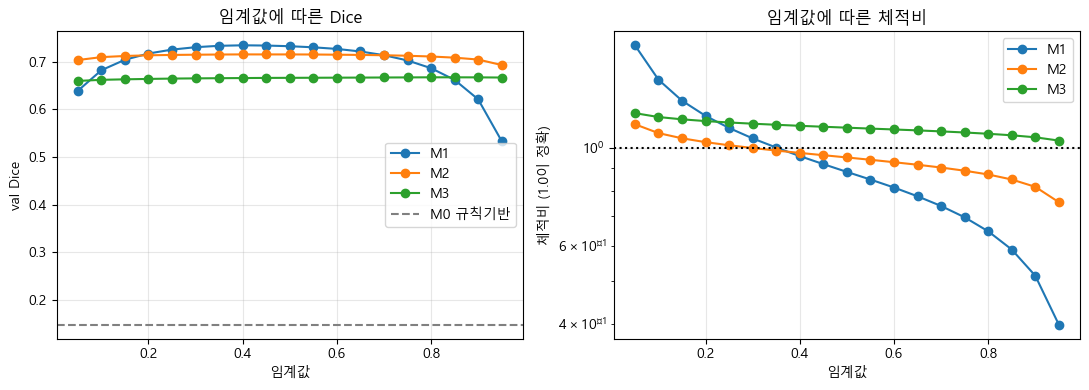

In [25]:
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
for name in ['M1', 'M2', 'M3']:
    sw = sweeps[name]
    plt.plot(sw['th'], sw['dice'], 'o-', label=name)
plt.axhline(0.1487, ls='--', c='gray', label='M0 규칙기반')
plt.xlabel('임계값'); plt.ylabel('val Dice'); plt.legend(); plt.grid(alpha=0.3)
plt.title('임계값에 따른 Dice')

plt.subplot(1, 2, 2)
for name in ['M1', 'M2', 'M3']:
    sw = sweeps[name]
    plt.plot(sw['th'], sw['vol_ratio'], 'o-', label=name)
plt.axhline(1.0, ls=':', c='k')
plt.xlabel('임계값'); plt.ylabel('체적비 (1.0이 정확)')
plt.yscale('log'); plt.legend(); plt.grid(alpha=0.3)
plt.title('임계값에 따른 체적비')
plt.tight_layout(); plt.show()

In [26]:
# 픽셀 재현율 말고 슬라이스 검출 재현율
MIN_PX = 20
for name, m in models.items():
    vp, vt = evaluate_seg(m, val_loader)
    t = BEST_T[name]
    pred_flag = ((vp > t).sum(axis=(1,2)) > MIN_PX).astype(int)
    true_flag = data['val'][2]['tumor'].values
    print(f"{name}  슬라이스 재현율 {recall_score(true_flag, pred_flag, zero_division=0):.4f}  "
          f"정밀도 {precision_score(true_flag, pred_flag, zero_division=0):.4f}")

M1  슬라이스 재현율 0.8679  정밀도 0.8178
M2  슬라이스 재현율 0.7736  정밀도 0.8200
M3  슬라이스 재현율 0.7123  정밀도 0.8580


# 결론
- m1이 val 기준 모든 지표에서 우수함.
    dice       슬라이스재현율      체적비    과적합격차
m1  0.7341     0.8679           0.92배      +0.1459   -> 과적합이 유일한 약점
m2  0.7155     0.7736           0.96배      +0.0776
m3  0.6664     0.7123           1.11배      +0.0083

In [ ]:
# ============================================================
# 셀 33. test 평가 — 세 층위
# ============================================================
MIN_PX = 20

def evaluate_full(model, loader, sub_df, threshold, name=""):
    probs, trues = evaluate_seg(model, loader)
    has = sub_df['tumor'].values.astype(bool)

    d_all = float(dice_score(probs, trues, threshold))
    d_pos = float(dice_score(probs[has], trues[has], threshold))
    vol   = float(volume_ratio(probs, trues, threshold))

    pred_flag  = ((probs > threshold).sum(axis=(1,2)) > MIN_PX).astype(int)
    true_flag  = has.astype(int)
    slice_area = (probs > threshold).sum(axis=(1,2)) / IMAGE_SIZE**2

    rec   = recall_score(true_flag, pred_flag, zero_division=0)
    prec  = precision_score(true_flag, pred_flag, zero_division=0)
    prauc = average_precision_score(true_flag, slice_area)
    cm    = confusion_matrix(true_flag, pred_flag)

    per_patient, missed = {}, {}
    for p, gp in sub_df.groupby('patient'):
        k = gp.index.values
        per_patient[p] = float(dice_score(probs[k], trues[k], threshold))
        m = gp.loc[(true_flag[k] == 1) & (pred_flag[k] == 0), 'slice'].tolist()
        if m: missed[p] = m

    pv = np.array(list(per_patient.values()))
    print(f"===== {name} (임계값 {threshold:.2f}) =====")
    print(f"[픽셀]    Dice {d_all:.4f} | 종양슬라이스만 {d_pos:.4f} | 체적비 {vol:.2f}배")
    print(f"[슬라이스] recall {rec:.4f} | precision {prec:.4f} | PR-AUC {prauc:.4f}")
    print(f"[환자]    n={len(pv)} 평균 {pv.mean():.4f} 중앙값 {np.median(pv):.4f} 최소 {pv.min():.4f}")
    print(f"[놓침]    종양 슬라이스를 놓친 환자 {len(missed)}명 / {len(pv)}명")
    return dict(dice=d_all, dice_pos=d_pos, vol=vol, recall=float(rec),
                precision=float(prec), prauc=float(prauc), cm=cm,
                per_patient=per_patient, missed=missed)

te_sub = data['test'][2]
res = {}
for name, m in models.items():
    res[name] = evaluate_full(m, test_loader, te_sub, BEST_T[name], name)
    print()

# 딱 한번만 돌림
# 또돌리면 편향 일어남.

===== M1 (임계값 0.45) =====
[픽셀]    Dice 0.6684 | 종양슬라이스만 0.7271 | 체적비 0.99배
[슬라이스] recall 0.9346 | precision 0.8065 | PR-AUC 0.8376
[환자]    n=16 평균 0.6875 중앙값 0.7851 최소 0.0773
[놓침]    종양 슬라이스를 놓친 환자 8명 / 16명

===== M2 (임계값 0.47) =====
[픽셀]    Dice 0.6568 | 종양슬라이스만 0.6667 | 체적비 0.66배
[슬라이스] recall 0.6822 | precision 0.9299 | PR-AUC 0.7735
[환자]    n=16 평균 0.5644 중앙값 0.6683 최소 0.0000
[놓침]    종양 슬라이스를 놓친 환자 15명 / 16명

===== M3 (임계값 0.50) =====
[픽셀]    Dice 0.6438 | 종양슬라이스만 0.6714 | 체적비 0.77배
[슬라이스] recall 0.6822 | precision 0.8902 | PR-AUC 0.7296
[환자]    n=16 평균 0.5666 중앙값 0.6711 최소 0.0000
[놓침]    종양 슬라이스를 놓친 환자 13명 / 16명



# TEST 결과
- 모델비교 : PR-AUC로 해야 공정 -> M1이 우위에있음. (임계값과 무관한 지표)
- 체적비 : M2 체적비가 심각함. VAL에서는 0.96 / TEST에서는 0.66 -> 과적합 또는 일반화가 약함. / M1은 VAL 0.92 -> 0.99로 좋아짐
- Dice : 환자 최소값 0.0000 으로 m2는 한 환자를 통채로 놓쳤음. / m2와 m3는 어떤 환자에서는 종양을 하나도 못찾았따라고 하는것임. / m1은 최소 무언가 표시는 해놨음 0.07수준



In [ ]:
# ============================================================
# 셀 34. 기관별 성능 + 실패 환자 확인 (찾기)
# ============================================================
BEST = 'M1'
pp = pd.Series(res[BEST]['per_patient'], name='dice').to_frame()
pp['inst'] = [p.split('_')[1] for p in pp.index]
pp['슬라이스'] = [int((te_sub.patient == p).sum()) for p in pp.index]
pp['종양슬라이스'] = [int(te_sub.loc[te_sub.patient == p, 'tumor'].sum()) for p in pp.index]
pp['놓친슬라이스'] = [len(res[BEST]['missed'].get(p, [])) for p in pp.index]

print("=== 기관별 ===")
print(pp.groupby('inst')['dice'].agg(['count', 'mean', 'min']).round(4))
print()
print("=== 환자별 (Dice 낮은 순) ===")
print(pp.sort_values('dice').round(4).to_string())

# 목적 
# 특정기관에서만 나쁜가 아니면 도메인상 문제인가?

=== 기관별 ===
      count    mean     min
inst                       
CS        2  0.4773  0.0773
DU        7  0.6739  0.3800
FG        2  0.7224  0.6017
HT        5  0.7767  0.6052

=== 환자별 (Dice 낮은 순) ===
                         dice inst  슬라이스  종양슬라이스  놓친슬라이스
TCGA_CS_5397_20010315  0.0773   CS    22       6       0
TCGA_DU_8163_19961119  0.3800   DU    37       5       0
TCGA_DU_5872_19950223  0.4795   DU    71      21       1
TCGA_DU_7018_19911220  0.5078   DU    36      18       0
TCGA_FG_7643_20021104  0.6017   FG    48       7       1
TCGA_HT_7855_19951020  0.6052   HT    21      11       0
TCGA_HT_A61B_19991127  0.6933   HT    88      25       4
TCGA_DU_7309_19960831  0.7636   DU    40       9       1
TCGA_DU_A5TP_19970614  0.8065   DU    38      12       0
TCGA_HT_7692_19960724  0.8173   HT    20       6       2
TCGA_FG_6689_20020326  0.8431   FG    48      20       2
TCGA_DU_7008_19830723  0.8554   DU    52      28       2
TCGA_HT_7694_19950404  0.8748   HT    21      14      

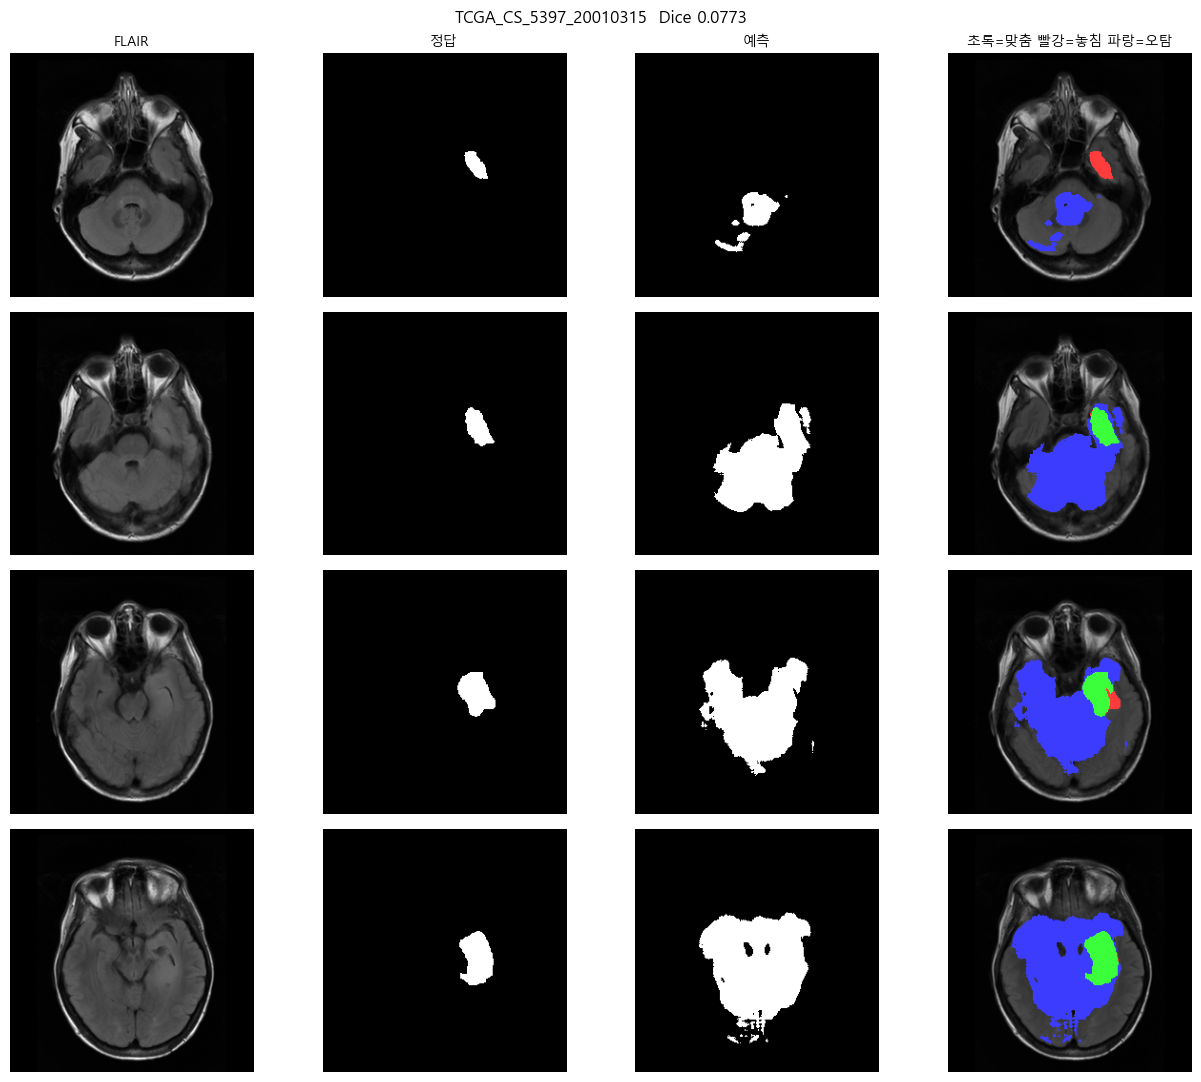

In [ ]:
# ============================================================
# 셀 35. 최악 환자 시각화
# ============================================================
worst = 'TCGA_CS_5397_20010315'
probs, trues = evaluate_seg(model_1, test_loader)
t = BEST_T['M1']

sub = te_sub[te_sub.patient == worst]
k = sub.index[sub.tumor == 1].values[:4]      # 종양 있는 슬라이스 4장

te_imgs, te_msks, _ = data['test']
plt.figure(figsize=(13, 11))
for r, i in enumerate(k):
    img = te_imgs[i]; msk = te_msks[i]
    pred = (probs[i] > t).astype(np.uint8)
    ov = np.stack([img[:, :, 1]] * 3, axis=-1)     # FLAIR 회색조 배경
    ov[(msk > 0) & (pred == 0)] = [255, 60, 60]    # 놓침
    ov[(msk == 0) & (pred == 1)] = [60, 60, 255]   # 오탐
    ov[(msk > 0) & (pred == 1)] = [60, 255, 60]    # 맞춤
    for c, (arr, ttl) in enumerate([(img[:, :, 1], 'FLAIR'), (msk, '정답'),
                                    (pred, '예측'), (ov, '초록=맞춤 빨강=놓침 파랑=오탐')]):
        plt.subplot(4, 4, r*4 + c + 1)
        plt.imshow(arr, cmap='gray' if arr.ndim == 2 else None); plt.axis('off')
        if r == 0: plt.title(ttl, fontsize=10)
plt.suptitle(f'{worst}  Dice {res["M1"]["per_patient"][worst]:.4f}')
plt.tight_layout(); plt.show()

# 파란색이 많으면 오탐임.

In [ ]:
pp['종양비율'] = pp['종양슬라이스'] / pp['슬라이스']
pp['평균종양px'] = [te_sub.loc[(te_sub.patient == p) & (te_sub.tumor == 1),
                                'tumor_px'].mean() for p in pp.index]
print(pp[['dice', '종양비율', '평균종양px']].sort_values('dice').round(3).to_string())
print()
print("상관계수")
print(pp[['dice', '종양비율', '평균종양px', '슬라이스']].corr()['dice'].round(3))



                        dice   종양비율    평균종양px
TCGA_CS_5397_20010315  0.077  0.273   846.333
TCGA_DU_8163_19961119  0.380  0.135   888.600
TCGA_DU_5872_19950223  0.480  0.296  2177.333
TCGA_DU_7018_19911220  0.508  0.500  4087.056
TCGA_FG_7643_20021104  0.602  0.146   726.714
TCGA_HT_7855_19951020  0.605  0.524  3621.273
TCGA_HT_A61B_19991127  0.693  0.284   905.800
TCGA_DU_7309_19960831  0.764  0.225   707.556
TCGA_DU_A5TP_19970614  0.806  0.316  1578.250
TCGA_HT_7692_19960724  0.817  0.300   519.167
TCGA_FG_6689_20020326  0.843  0.417  2580.850
TCGA_DU_7008_19830723  0.855  0.538  2590.143
TCGA_HT_7694_19950404  0.875  0.667  3351.214
TCGA_CS_4943_20000902  0.877  0.400  1816.875
TCGA_HT_7690_19960312  0.893  0.375  2839.556
TCGA_DU_5871_19941206  0.925  0.417  2551.000

상관계수
dice      1.000
종양비율      0.416
평균종양px    0.241
슬라이스     -0.056
Name: dice, dtype: float64


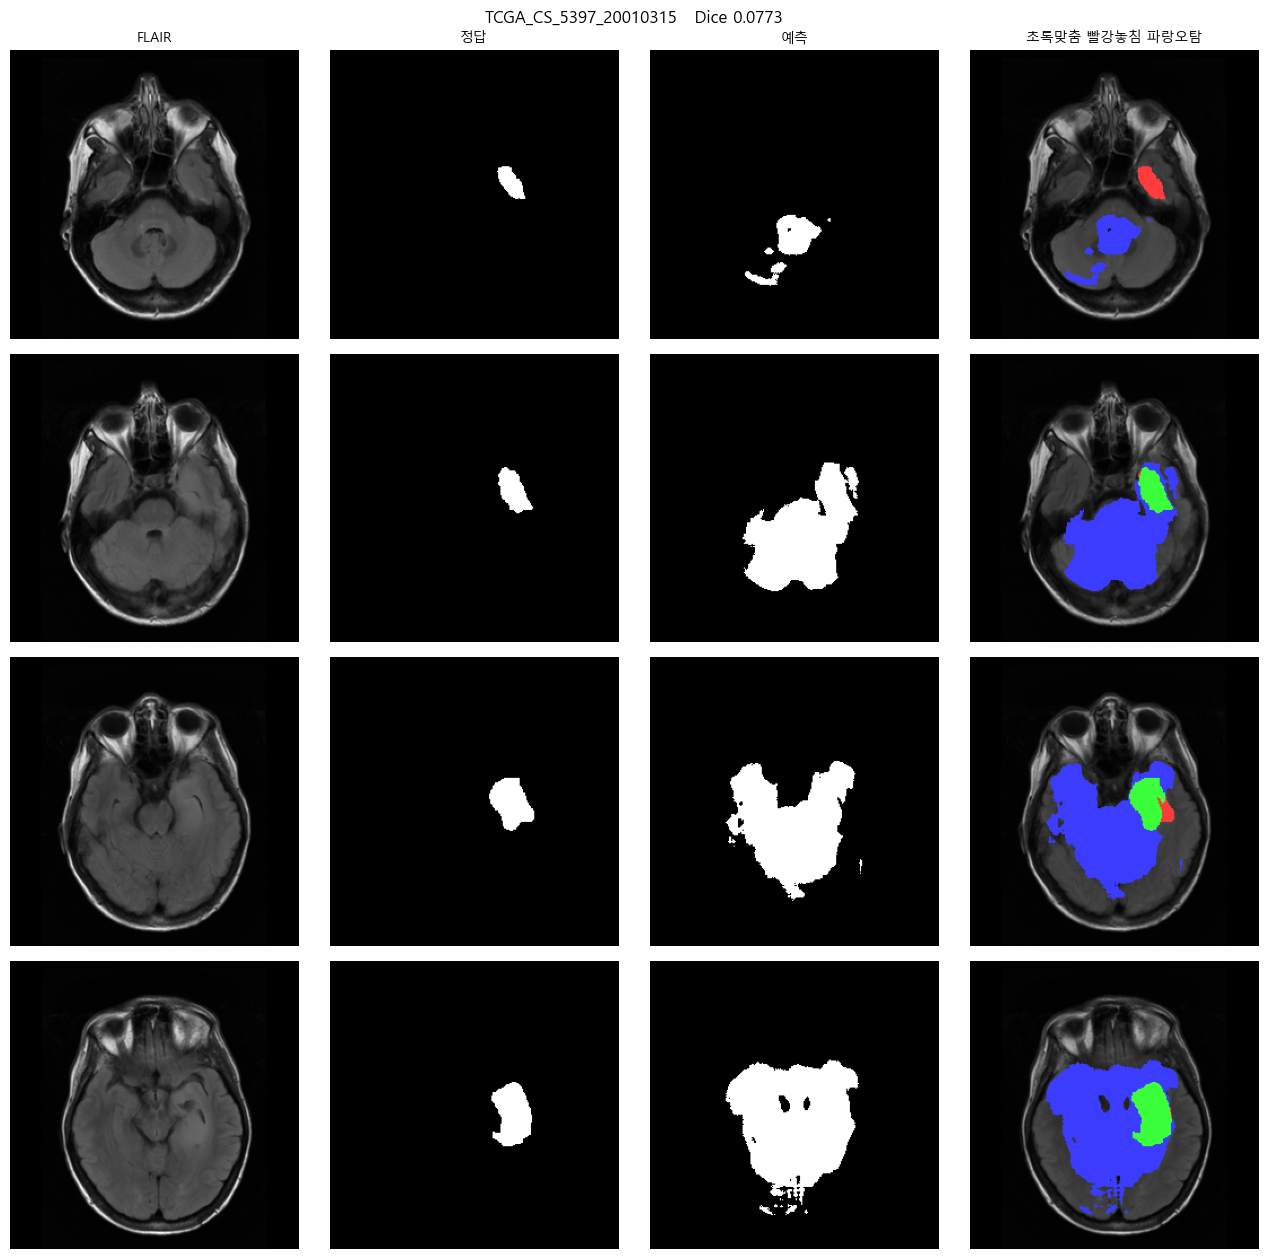

In [33]:
# ============================================================
# 셀 35. 실패 환자 두 유형 시각화
# ============================================================
probs, trues = evaluate_seg(model_1, test_loader)
t = BEST_T['M1']
te_imgs, te_msks, _ = data['test']

def show_patient(pid, n_show=4):
    sub = te_sub[te_sub.patient == pid]
    k = sub.index[sub.tumor == 1].values
    k = k[::max(1, len(k)//n_show)][:n_show]

    plt.figure(figsize=(13, 3.2 * len(k)))
    for r, i in enumerate(k):
        img, msk = te_imgs[i], te_msks[i]
        pred = (probs[i] > t).astype(np.uint8)
        ov = np.stack([img[:, :, 1]] * 3, axis=-1)
        ov[(msk > 0) & (pred == 0)] = [255, 60, 60]
        ov[(msk == 0) & (pred == 1)] = [60, 60, 255]
        ov[(msk > 0) & (pred == 1)] = [60, 255, 60]
        for c, (arr, ttl) in enumerate([(img[:, :, 1], 'FLAIR'), (msk, '정답'),
                                        (pred, '예측'), (ov, '초록맞춤 빨강놓침 파랑오탐')]):
            plt.subplot(len(k), 4, r*4 + c + 1)
            plt.imshow(arr, cmap='gray' if arr.ndim == 2 else None); plt.axis('off')
            if r == 0: plt.title(ttl, fontsize=10)
    plt.suptitle(f'{pid}   Dice {res["M1"]["per_patient"][pid]:.4f}')
    plt.tight_layout(); plt.show()

show_patient('TCGA_CS_5397_20010315')     # 유형 A: 작은 종양, Dice 0.077

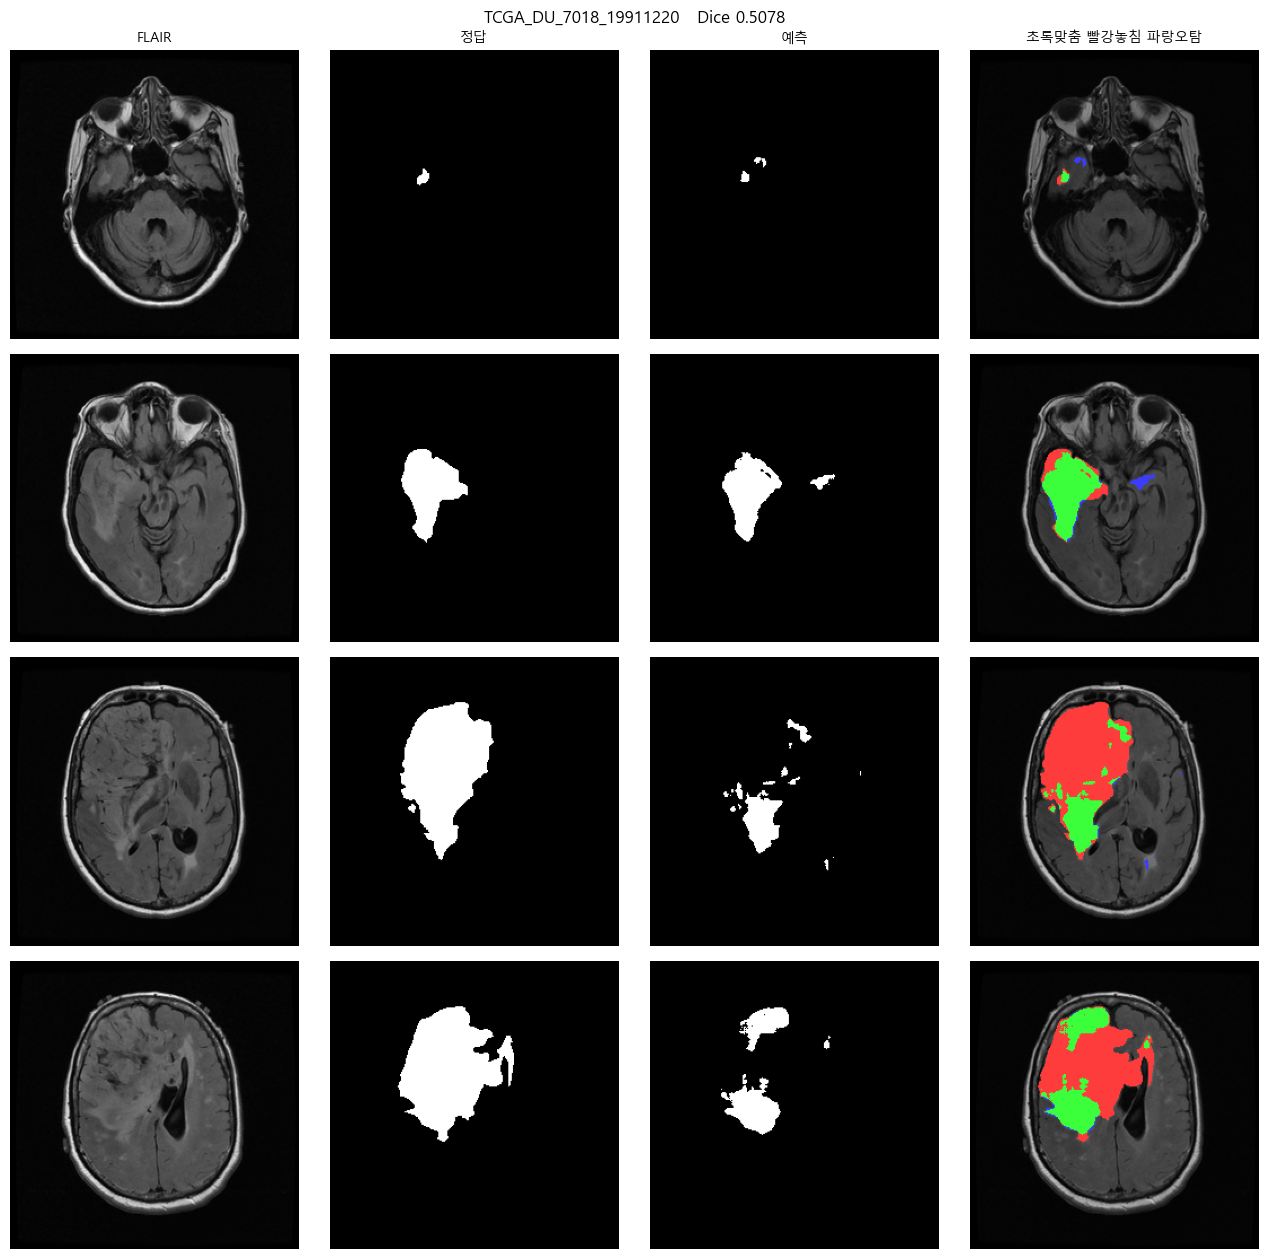

In [ ]:
show_patient('TCGA_DU_7018_19911220')     # Dice 0.508, 평균 4087px
# 과대예측 (종양은 찾았는데 주변까지 다 칠함.)

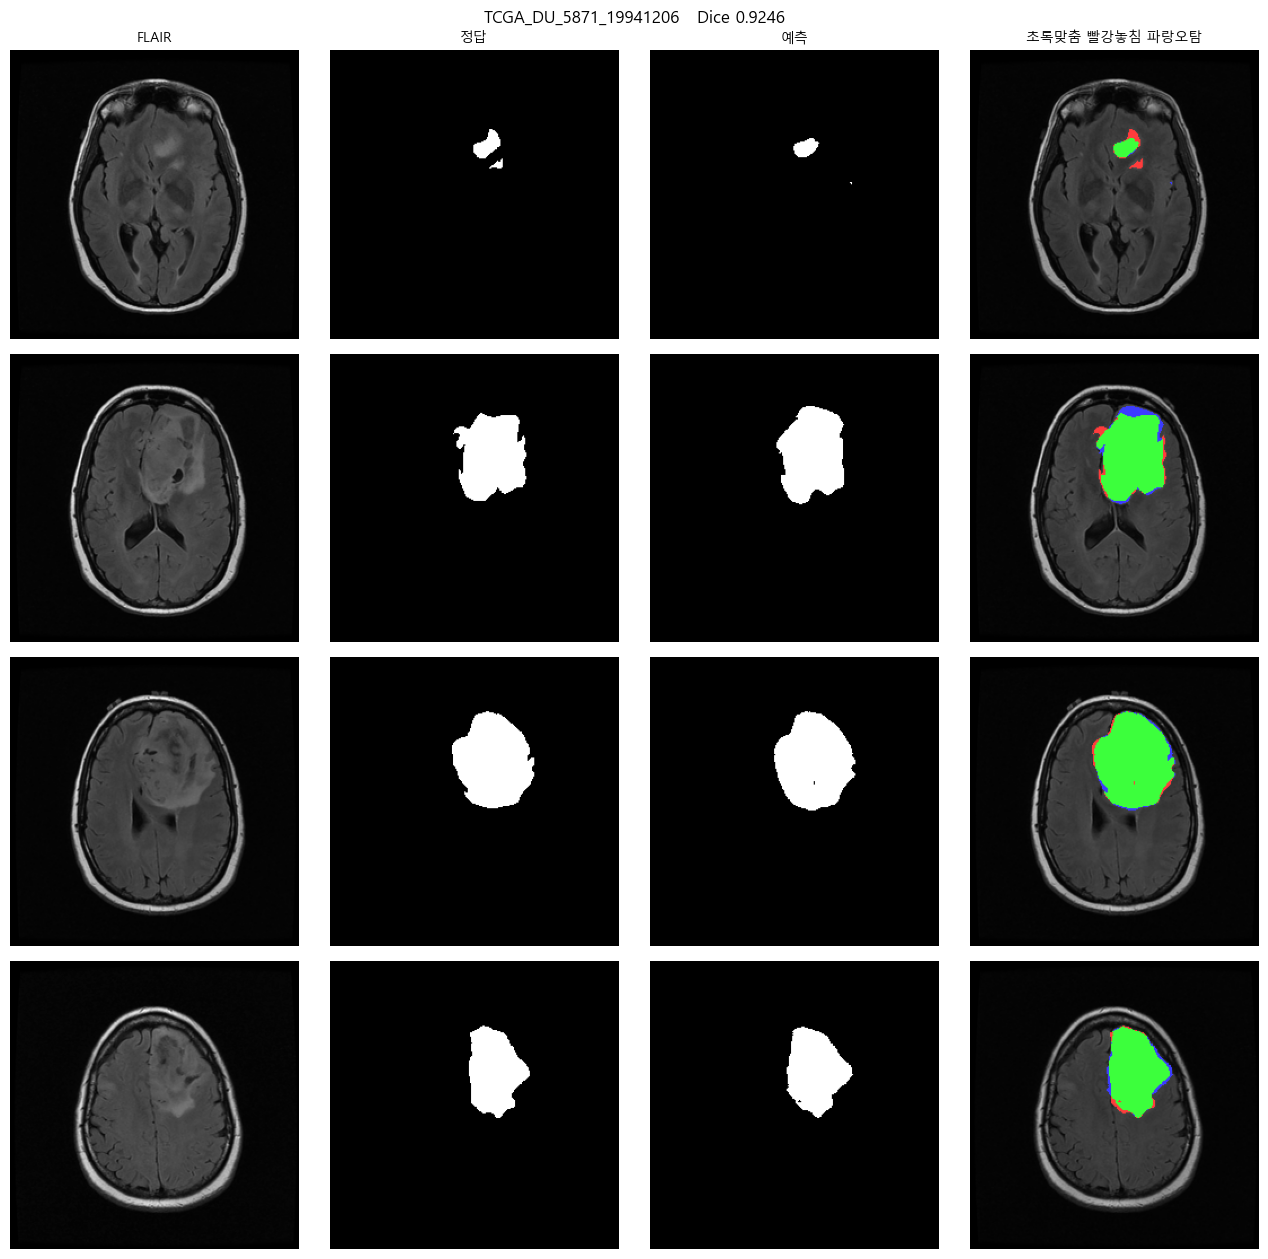

In [ ]:
show_patient('TCGA_DU_5871_19941206')     # Dice 0.925
# 과소예측 ( 종양의 3분의 2이상을 놓침.)

In [36]:
# 놓친 이유 : flair 원본을 봣을떄 종양이 있는 왼쪽 영ㅇ역이 주변 뇌조직과 밝기가 거의 같아서.
# 성공사례는 종양이 눈에 띄가 밝은 덩어리로 보임 / 경계도 뚜렷함.

In [37]:
# ============================================================
# 셀 36. 가설검정 — 대응표본 정확 순열검정 (numpy만 사용)
# ============================================================
def exact_sign_test(diff):
    """부호 뒤집기 전수 계산. n<=22 에서 정확한 p값"""
    n = len(diff)
    signs = ((np.arange(2**n)[:, None] >> np.arange(n)) & 1) * 2 - 1
    null = (signs * np.abs(diff)).mean(axis=1)
    return float((np.abs(null) >= abs(diff.mean()) - 1e-12).mean())

def bootstrap_ci(diff, n_boot=10000, seed=SEED):
    rng = np.random.default_rng(seed)
    b = [diff[rng.integers(0, len(diff), len(diff))].mean() for _ in range(n_boot)]
    return np.percentile(b, [2.5, 97.5])

pat  = sorted(res['M1']['per_patient'].keys())
d_a  = np.array([res['M1']['per_patient'][p] for p in pat])
d_b  = np.array([res['M2']['per_patient'][p] for p in pat])
diff = d_b - d_a

p_val  = exact_sign_test(diff)
lo, hi = bootstrap_ci(diff)

print(f"대응표본 정확 순열검정 (환자 n={len(pat)})")
print(f"  M1 중앙값 Dice  {np.median(d_a):.4f}")
print(f"  M2 중앙값 Dice  {np.median(d_b):.4f}")
print(f"  중앙값 차이     {np.median(diff):+.4f}")
print(f"  M2가 나은 환자   {(diff > 0).sum()} / {len(pat)}")
print(f"  p = {p_val:.4f}")
print(f"  95% 신뢰구간    [{lo:+.4f}, {hi:+.4f}]")
print()
print("판정:", "H0 기각" if p_val < 0.05 else "H0 기각 실패 (차이를 확인하지 못함)")

대응표본 정확 순열검정 (환자 n=16)
  M1 중앙값 Dice  0.7851
  M2 중앙값 Dice  0.6683
  중앙값 차이     -0.0947
  M2가 나은 환자   5 / 16
  p = 0.0293
  95% 신뢰구간    [-0.2311, -0.0288]

판정: H0 기각


결과 해석

신뢰구간이 0을 포함하지 않습니다. [-0.2311, -0.0288] 전체가 음수. 이게 p값보다 더 강한 근거입니다.

**"M2가 M1보다 평균 0.03~0.23 낮다"**고 말할 수 있음. 방향과 크기가 모두 확정.

16명 중 11명에서 M1이 나았습니다. 5명은 M2가 나았고요. 압도적이진 않지만 일관된 경향입니다.

p = 0.0293이 뜻하는 것

**"M1과 M2가 실제로 같다면, 이만큼의 차이가 우연히 나올 확률이 2.93%"**입니다.

관례적으로 5% 미만이면 "우연으로 보기 어렵다"고 판단해요. 그래서 H0(차이 없음)를 기각합니다.


M1과 M2의 성능 차이를 환자 단위 대응표본 정확 순열검정으로 평가하였다.
검정 단위를 슬라이스(n=622)가 아닌 환자(n=16)로 설정한 것은
동일 환자의 인접 슬라이스가 높은 상관을 가져 독립성 가정을 위반하기 때문이다.

결과는 M1 중앙값 0.7851, M2 중앙값 0.6683, 중앙값 차이 -0.0947이었으며
p = 0.0293으로 유의수준 0.05에서 귀무가설을 기각하였다.
부트스트랩 95% 신뢰구간은 [-0.2311, -0.0288]로 0을 포함하지 않아
차이의 방향이 확정적이다. 16명 중 11명에서 M1이 우수하였다.

scipy를 사용하지 않고 numpy만으로 부호 뒤집기 2^16 = 65,536가지를
전수 계산하여 근사가 아닌 정확 p값을 산출하였음


In [38]:
d_c = np.array([res['M3']['per_patient'][p] for p in pat])

for other, arr in [('M2', d_b), ('M3', d_c)]:
    diff = arr - d_a
    p_val = exact_sign_test(diff)
    lo, hi = bootstrap_ci(diff)
    print(f"M1 vs {other}  중앙값차 {np.median(diff):+.4f}  "
          f"p={p_val:.4f}  CI[{lo:+.4f}, {hi:+.4f}]  "
          f"{other} 우세 {(diff>0).sum()}/{len(pat)}")

M1 vs M2  중앙값차 -0.0947  p=0.0293  CI[-0.2311, -0.0288]  M2 우세 5/16
M1 vs M3  중앙값차 -0.0674  p=0.0399  CI[-0.2325, -0.0181]  M3 우세 4/16


M1을 기준으로 M2, M3와 각각 대응표본 정확 순열검정을 수행하였다.
M1 vs M2는 중앙값 차이 -0.0947 (p = 0.0293, 95% CI [-0.2311, -0.0288]),
M1 vs M3는 -0.0674 (p = 0.0399, 95% CI [-0.2325, -0.0181])였다.

2회의 비교를 수행하였으므로 Bonferroni 보정 시 유의수준은 0.025이며,
두 p값 모두 이를 상회하여 보정 기준으로는 유의하지 않다.
다만 두 비교 모두 95% 신뢰구간이 0을 포함하지 않고,
16명 중 각각 11명과 12명에서 M1이 우수하여 방향이 일관되었다.
따라서 M1의 우위는 통계적으로 확정되지는 않았으나
실질적 차이가 존재할 가능성이 높은 것으로 판단된다.

본 검정의 한계는 test 환자가 16명으로 검정력이 낮다는 점이다.
표본이 작을수록 다중검정 보정의 부담이 커지므로,
향후 교차검증을 통해 표본을 확보한 재검정이 필요하다.

In [40]:
# ============================================================
# 셀 37. 전체 결과 저장
# ============================================================
tests = {}
for other, arr in [('M2', d_b), ('M3', d_c)]:
    diff = arr - d_a
    lo, hi = bootstrap_ci(diff)
    tests[f'M1_vs_{other}'] = {
        'median_diff': float(np.median(diff)),
        'p_value': float(exact_sign_test(diff)),
        'ci95': [float(lo), float(hi)],
        f'{other}_win': int((diff > 0).sum()),
        'n': len(pat),
    }

summary = {
    '환경': {'device': str(device), 'torch': torch.__version__,
             'GPU': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None},
    '설정': {'BASE': BASE, 'IMAGE_SIZE': IMAGE_SIZE, 'BATCH_SIZE': BATCH_SIZE,
             'EPOCHS': EPOCHS, 'NEG_RATIO': NEG_RATIO, 'SEED': SEED, 'AMP': USE_AMP},
    '분할': {sp: {'환자': int(df.loc[df.split==sp, 'patient'].nunique()),
                  '슬라이스': int((df.split==sp).sum())} for sp in ['train','val','test']},
    'M0_규칙기반': {
        'dice': float(dice_score(P0, te_msks)),
        'volume_ratio': float(volume_ratio(P0, te_msks)),
        'slice_recall': float(recall_score(flag_true, flag_pred, zero_division=0)),
    },
    '임계값': BEST_T,
    '에폭평균초': {k: float(np.mean(h['sec']))
                   for k, h in [('M1',hist_1),('M2',hist_2),('M3',hist_3)]},
    '과적합격차': {k: float(h['train_dice'][-1] - h['val_dice'][-1])
                   for k, h in [('M1',hist_1),('M2',hist_2),('M3',hist_3)]},
    'test결과': {k: {kk: vv for kk, vv in v.items()
                     if kk not in ('cm', 'per_patient', 'missed')}
                 for k, v in res.items()},
    '환자별_Dice': res['M1']['per_patient'],
    '가설검정': tests,
    '최종모델': 'M1',
}

with open('results.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("results.json 저장 완료")
print(json.dumps({k: v for k, v in summary.items()
                  if k not in ('환자별_Dice',)}, ensure_ascii=False, indent=2)[:2000])

results.json 저장 완료
{
  "환경": {
    "device": "cuda",
    "torch": "2.11.0+cu128",
    "GPU": "NVIDIA GeForce RTX 5060 Laptop GPU"
  },
  "설정": {
    "BASE": 32,
    "IMAGE_SIZE": 256,
    "BATCH_SIZE": 16,
    "EPOCHS": 30,
    "NEG_RATIO": 1.0,
    "SEED": 42,
    "AMP": true
  },
  "분할": {
    "train": {
      "환자": 78,
      "슬라이스": 2742
    },
    "val": {
      "환자": 16,
      "슬라이스": 565
    },
    "test": {
      "환자": 16,
      "슬라이스": 622
    }
  },
  "M0_규칙기반": {
    "dice": 0.14865586579713722,
    "volume_ratio": 3.635497897573669,
    "slice_recall": 1.0
  },
  "임계값": {
    "M1": 0.45,
    "M2": 0.475,
    "M3": 0.5
  },
  "에폭평균초": {
    "M1": 18.52159451643626,
    "M2": 19.792578879992167,
    "M3": 19.829118124643962
  },
  "과적합격차": {
    "M1": 0.14587497518974157,
    "M2": 0.07755339649820847,
    "M3": 0.008251853260405229
  },
  "test결과": {
    "M1": {
      "dice": 0.6684259964273302,
      "dice_pos": 0.7271116620053738,
      "vol": 0.9912929605621091,
      "rec